<a href="https://colab.research.google.com/github/tgesell/WindTurbineFarms/blob/main/wind_turbines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This Code Cell Mounts the user's Google Drive, so that the code in this notebook can access the Google Drive as storage.

In [1]:
#commented out because reading file from public github repository instead of google drive.
#from google.colab import drive
#drive.mount('/content/drive')



This Code cell reads the data from the file:  wind_turbines.csv and stores it as a collection of records (rows), in a pandas data_frame data structure.  It then groups the data by state (collecting together all of the rows with the same state in the first column), and sums up the values from the 10th column, Number_Turbines, for each state.  It then sorts the data in decending order by Number_Of_turbines in each state.

In [2]:
# read a .csv file called wind_turbines.csv.  Each line of the file represents a wind turbine farm.
# The first column, Site.State,  is state name where the wind farm is located.
# The 10th column, Project.Number_Turbines is the number of turbines on that farm.

import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file into a pandas DataFrame
try:
  #data_frame = pd.read_csv('/content/drive/My Drive/Classroom/IB_AP Comp Sci/Java Projects/Wind_Turbines/wind_turbines.csv')
  data_frame = pd.read_csv('https://raw.githubusercontent.com/tgesell/WindTurbineFarms/refs/heads/main/wind_turbines.csv')
except FileNotFoundError:
  print("Error: 'wind_turbines.csv' not found. Please upload the file to your Colab environment.")
  exit()

list_of_rows = data_frame.values.tolist()

# Group by State.  For each group, get the collection of Number_Turbines for that group, and get the sum of each collection.
# Store this as a dataframe of state/number_of_turbine pairs in state_turbine_counts
state_turbine_counts = data_frame.groupby('Site.State')['Project.Number_Turbines'].sum()


# Sort the states by the number of turbines in descending order
sorted_states = state_turbine_counts.sort_values(ascending=False)



This code cell simply prints the resulting data_frame, sorted_states, showing the number of turbines in each state.

In [ ]:
print(sorted_states)

Site.State
TX    1329923
CA     531196
IA     421475
KS     325075
CO     302614
OK     302380
IL     262154
MN     195151
WA     184729
IN     126217
OR     124333
ND     103778
NE      88225
NM      83816
NY      70650
WY      57052
MI      48659
MO      47894
MT      36016
SD      33186
OH      31188
WI      29506
PA      26680
WV      21729
ID      21595
ME      11852
NC      10816
UT      10323
AZ       5956
NV       4356
HI       2181
PR       2114
NH       1835
MD       1585
VT        855
AK        839
MA        552
TN        234
RI         70
NJ         26
CT          4
DE          1
GU          1
Name: Project.Number_Turbines, dtype: int64


This code cell simply builds a bar graph of that same data with State on the x-axis and number of turbines on the y-axis

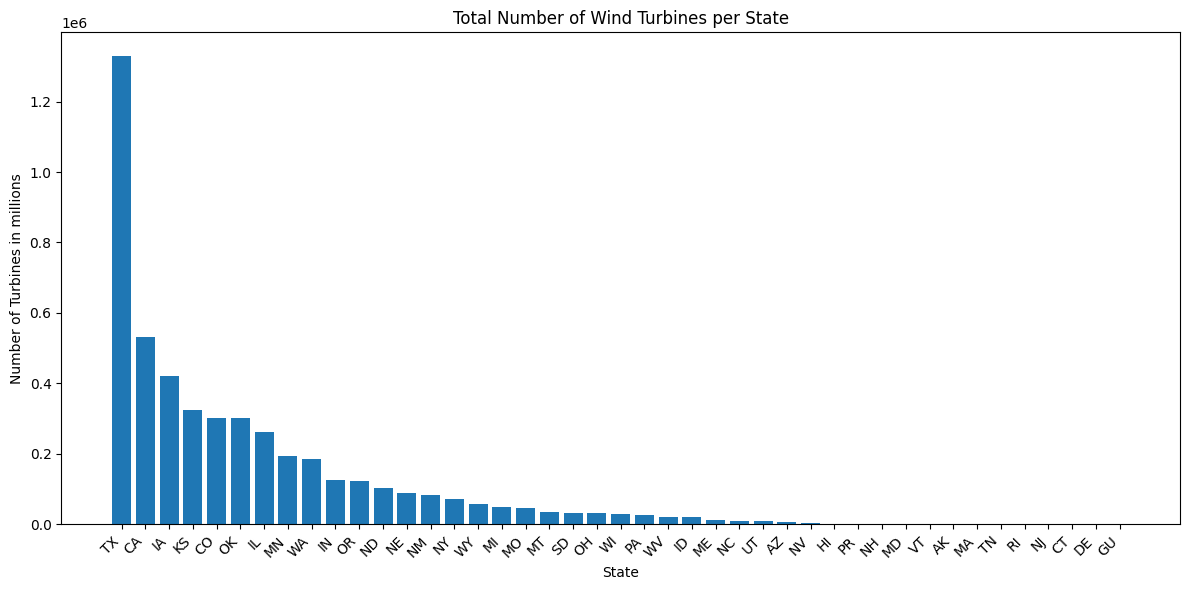

In [ ]:
# Create the bar graph
plt.figure(figsize=(12, 6))  # Adjust figure size
plt.bar(sorted_states.index, sorted_states.values)
plt.xlabel('State')
plt.ylabel('Number of Turbines in millions')
plt.title('Total Number of Wind Turbines per State')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout() # prevents labels from overlapping
plt.show()
